In [2]:
import pandas as pd
from cdc_ml.config import BOOKING_CYCLES_PROCESSED,RECORDS_PROCESSED,PREFERENCE_PROCESSED,CUSTOMER_CLASS_INTERIM
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

2026-05-11 14:42:12.921 | INFO     | cdc_ml.config:<module>:12 - PROJ_ROOT path is: C:\Users\zhiju\Desktop\cdc_ml


In [3]:

df_cycle = pd.read_parquet(BOOKING_CYCLES_PROCESSED)
df_records = pd.read_parquet(RECORDS_PROCESSED)
df_pref = pd.read_parquet(PREFERENCE_PROCESSED)

In [4]:
df_cycle.head()

,id,username,preference,range,cycle_end_reason,cycle_start,cycle_end
0,0,ajithak,"monday to saturday after 5pm , sunday anytime",till next week,completed,2025-08-19 09:15:00+08:00,2025-08-21 11:00:00+08:00
1,1,addity,"weeday after 7 , no tues and thurs",before oct,completed,2025-08-13 21:00:00+08:00,2025-08-28 11:36:00+08:00
2,2,addity,"anytime on weekends , weekday after 630pm",26 oct to 14 dec,completed,2025-10-17 00:00:00+08:00,2025-10-17 20:00:00+08:00
3,3,addity,"friday and weekends anytime, other weekdays af...",Jan and feb,completed,2026-01-16 20:00:00+08:00,2026-01-19 00:00:00+08:00
4,4,bryan,"before 25 sept , weekday after 730pm , 12 pm o...",NaN,completed,2025-08-22 00:48:00+08:00,2025-09-05 16:00:00+08:00


In [5]:
df_records.head()

,id,username,lesson_at,booking_at,booking_type,class_type,is_one_team
0,0,ajithak,2025-08-28 18:50:00+08:00,2025-08-21 09:24:06.300383+08:00,0,3,0
1,1,ajithak,2025-08-28 20:40:00+08:00,2025-08-21 09:24:16.048708+08:00,0,3,0
2,2,addity,2025-09-21 14:35:00+08:00,2025-08-23 00:57:26.576198+08:00,0,3a,1
3,3,bryan,2025-08-28 20:40:00+08:00,2025-08-25 12:06:06.539664+08:00,0,3a,0
4,4,bryan,2025-08-31 12:45:00+08:00,2025-08-26 12:50:24.317931+08:00,0,3a,0


In [6]:
df_pref.head()

,id,username,day_of_week,day_name,pref_start,pref_end,date,t_0830,t_1020,t_1245,t_1435,t_1625,t_1850,t_2040
0,0,ajithak,1,Tuesday,2025-08-19,2025-08-31,2025-08-19,0,0,0,0,0,1,1
1,0,ajithak,2,Wednesday,2025-08-19,2025-08-31,2025-08-20,0,0,0,0,0,1,1
2,0,ajithak,3,Thursday,2025-08-19,2025-08-31,2025-08-21,0,0,0,0,0,1,1
3,0,ajithak,4,Friday,2025-08-19,2025-08-31,2025-08-22,0,0,0,0,0,1,1
4,0,ajithak,5,Saturday,2025-08-19,2025-08-31,2025-08-23,0,0,0,0,0,1,1


In [7]:
df_class = pd.read_parquet(CUSTOMER_CLASS_INTERIM)

In [8]:
df_class = df_class.drop_duplicates()

In [9]:
df_class.head()

,username,class_type,is_one_team
0,admin user,3a,0
1,jj,3a,0
2,b,3a,0
3,g,3a,0
4,shahtiya,CLASS 3 PRACTICAL TEST,0


In [10]:
df_pref = df_pref.merge(df_class,on="username",how="left")

df_records = df_records.assign(day_of_week=df_records["booking_at"].dt.day_of_week)

In [11]:
df_pref.info()

<class 'pandas.DataFrame'>
RangeIndex: 3985 entries, 0 to 3984
Data columns (total 16 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   id           3985 non-null   int64         
 1   username     3985 non-null   str           
 2   day_of_week  3985 non-null   int64         
 3   day_name     3985 non-null   str           
 4   pref_start   3985 non-null   datetime64[us]
 5   pref_end     3985 non-null   datetime64[us]
 6   date         3985 non-null   datetime64[us]
 7   t_0830       3985 non-null   int64         
 8   t_1020       3985 non-null   int64         
 9   t_1245       3985 non-null   int64         
 10  t_1435       3985 non-null   int64         
 11  t_1625       3985 non-null   int64         
 12  t_1850       3985 non-null   int64         
 13  t_2040       3985 non-null   int64         
 14  class_type   3985 non-null   str           
 15  is_one_team  3985 non-null   int64         
dtypes: datetime64[us]

In [12]:
week = ["Mon","Tue","Wed","Thu","Fri","Sat","Sun"]

In [13]:
n_customers = df_records.drop_duplicates("username").value_counts(["class_type","is_one_team"])
n_records   = df_records.value_counts(["class_type","is_one_team"])
print(n_customers)
print(n_records)

summary = pd.concat([
    n_customers,
    n_customers / n_customers.sum() * 100,
    n_records,
    n_records / n_records.sum() * 100,
    n_records / n_customers,    # records per customer — the "intensity" view
], axis=1, keys=["n_cust", "cust_pct", "n_rec", "rec_pct", "rec_per_cust"])

class_type  is_one_team
3a          0              17
3           0               9
3a          1               8
3           1               3
Name: count, dtype: int64
class_type  is_one_team
3a          0              271
3           0              142
3a          1               97
3           1               14
Name: count, dtype: int64


In [14]:
summary

,,n_cust,cust_pct,n_rec,rec_pct,rec_per_cust
class_type,is_one_team,,,,,
3a,0,17,45.945946,271,51.717557,15.941176
3,0,9,24.324324,142,27.099237,15.777778
3a,1,8,21.621622,97,18.511450,12.125000
3,1,3,8.108108,14,2.671756,4.666667


In [15]:
df_pref.info()

<class 'pandas.DataFrame'>
RangeIndex: 3985 entries, 0 to 3984
Data columns (total 16 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   id           3985 non-null   int64         
 1   username     3985 non-null   str           
 2   day_of_week  3985 non-null   int64         
 3   day_name     3985 non-null   str           
 4   pref_start   3985 non-null   datetime64[us]
 5   pref_end     3985 non-null   datetime64[us]
 6   date         3985 non-null   datetime64[us]
 7   t_0830       3985 non-null   int64         
 8   t_1020       3985 non-null   int64         
 9   t_1245       3985 non-null   int64         
 10  t_1435       3985 non-null   int64         
 11  t_1625       3985 non-null   int64         
 12  t_1850       3985 non-null   int64         
 13  t_2040       3985 non-null   int64         
 14  class_type   3985 non-null   str           
 15  is_one_team  3985 non-null   int64         
dtypes: datetime64[us]

In [16]:

slot_cols = ["t_0830", "t_1020", "t_1245", "t_1435", "t_1625", "t_1850", "t_2040"]

df_melt = df_pref.melt(
    id_vars=["username", "class_type", "is_one_team","day_of_week"],
    value_vars=slot_cols,
    var_name="slots",
    value_name="available",
).query("available == 1")

    


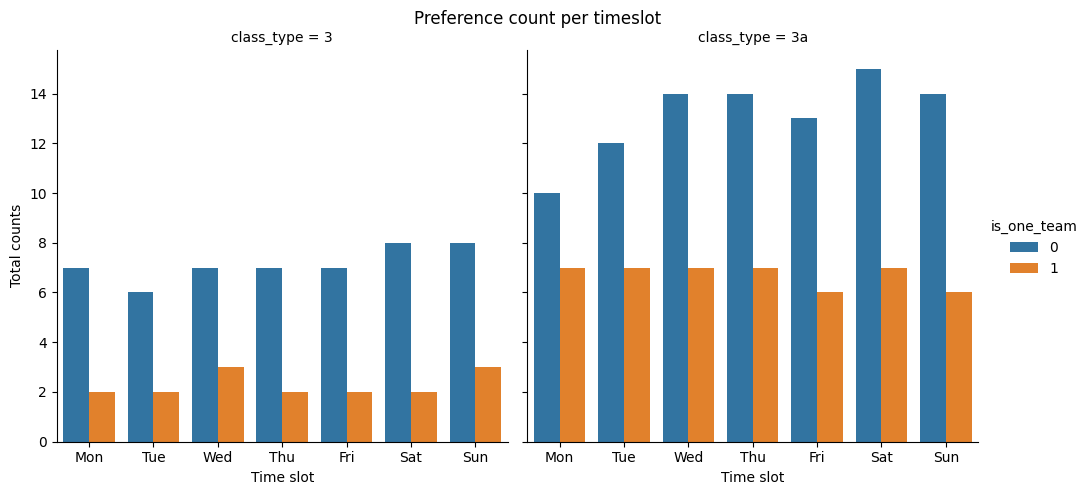

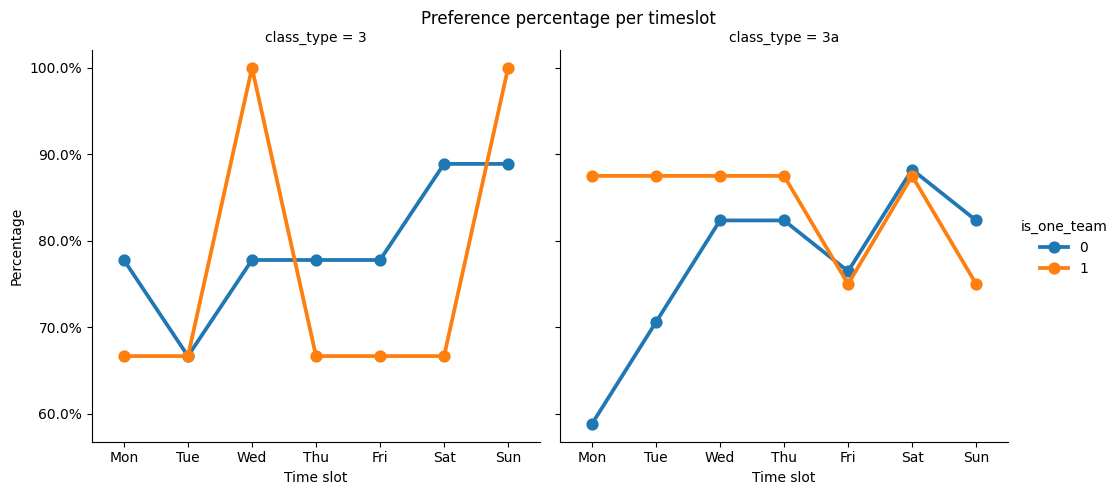

In [ ]:
import matplotlib.ticker as mtick

def get_slot_preference(df:pd.DataFrame):
    # users available per (slot, class_type, is_one_team)
    counts = (
        df.groupby(["slots", "class_type", "is_one_team"])["username"]
        .nunique()
        .reset_index(name="count")
    )

    # group sizes — denominator
    totals = (
        df.groupby(["class_type", "is_one_team"])["username"]
        .nunique()
        .reset_index(name="total")
    )

    merged = counts.merge(totals, on=["class_type", "is_one_team"])
    merged["share"] = merged["count"] / merged["total"]


    g1 = sns.catplot(
        data=counts,
        x="slots",
        y="count",
        hue="is_one_team",
        col="class_type",
        kind="bar"
    )
    g1.set_axis_labels("Time slot","Total counts")
    g1.figure.suptitle("Preference count per timeslot")
    g1.figure.subplots_adjust(top=0.9)
    for ax in g1.axes.flat:
        ax.set_xticks(range(len(week)))
        ax.set_xticklabels(week)


    g2 = sns.catplot(
        data=merged, kind="point",
        x="slots", y="share",
        hue="is_one_team", col="class_type"
    )
    g2.set_axis_labels("Time slot", "Percentage")
    g2.figure.suptitle("Preference percentage per timeslot")
    g2.figure.subplots_adjust(top=0.9)

    for ax in g2.axes.flat:
        ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
        ax.set_xticks(range(len(week)))
        ax.set_xticklabels(week)

get_slot_preference(df_melt)

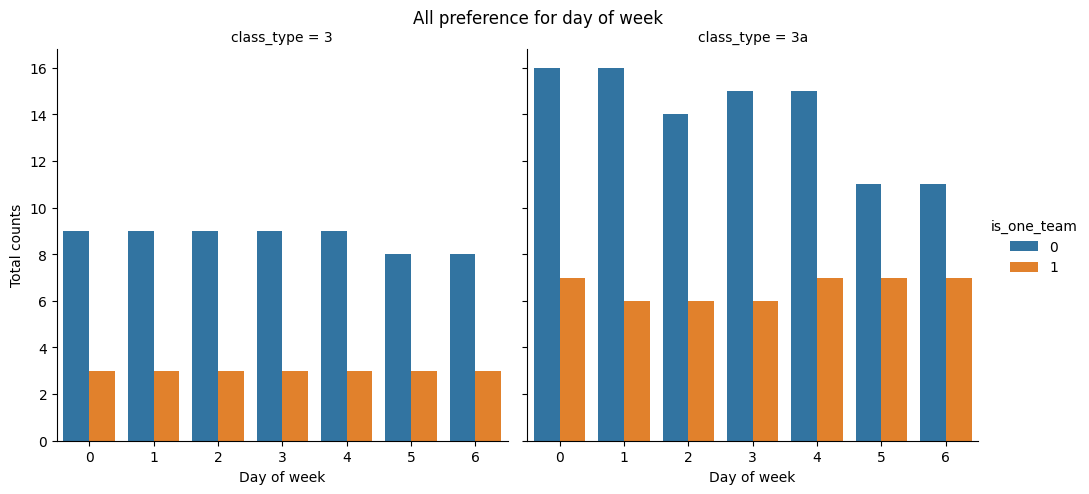

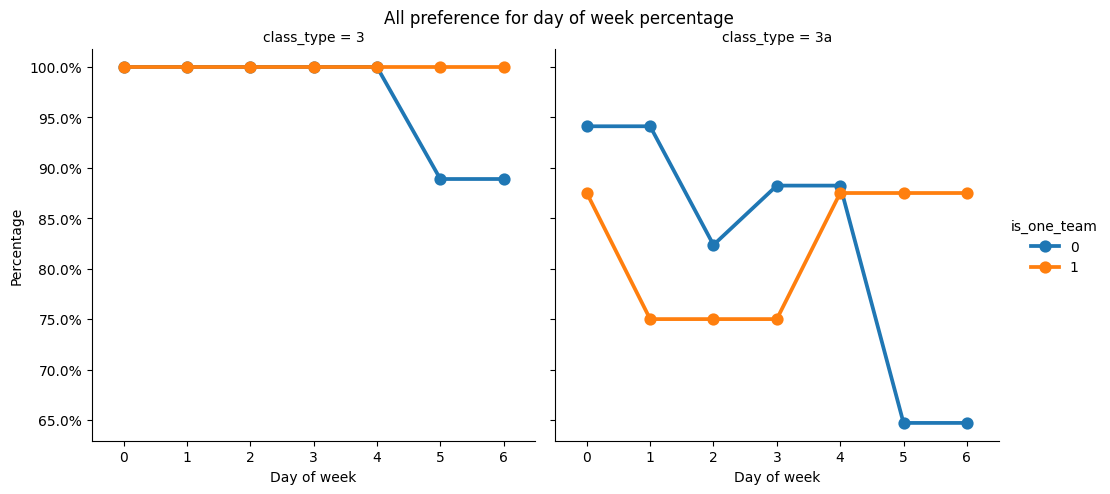

In [18]:
def get_day_preference(df:pd.DataFrame):
    counts = df.groupby(["day_of_week","class_type","is_one_team"])["username"].nunique().reset_index(name="count")
    g1 = sns.catplot(
        data=counts,x="day_of_week",y="count",hue="is_one_team",col="class_type",kind="bar"
    )
    g1.set_axis_labels("Day of week","Total counts")
    g1.figure.suptitle("All preference for day of week")
    g1.figure.subplots_adjust(top=0.9)

    total = df.groupby(["class_type","is_one_team"])["username"].nunique().reset_index(name="total")
    
    merged = counts.merge(total,on=["class_type","is_one_team"],how="left")
    merged["perc"] = merged["count"]/merged["total"]
    g2= sns.catplot(
        data=merged,x="day_of_week",y="perc",hue="is_one_team",col="class_type",kind="point"

    )
    g2.set_axis_labels("Day of week","Percentage")
    g2.figure.suptitle("All preference for day of week percentage")
    g2.figure.subplots_adjust(top=0.9)
    for ax in g2.axes.flat:
        ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
        
    

get_day_preference(df_pref)

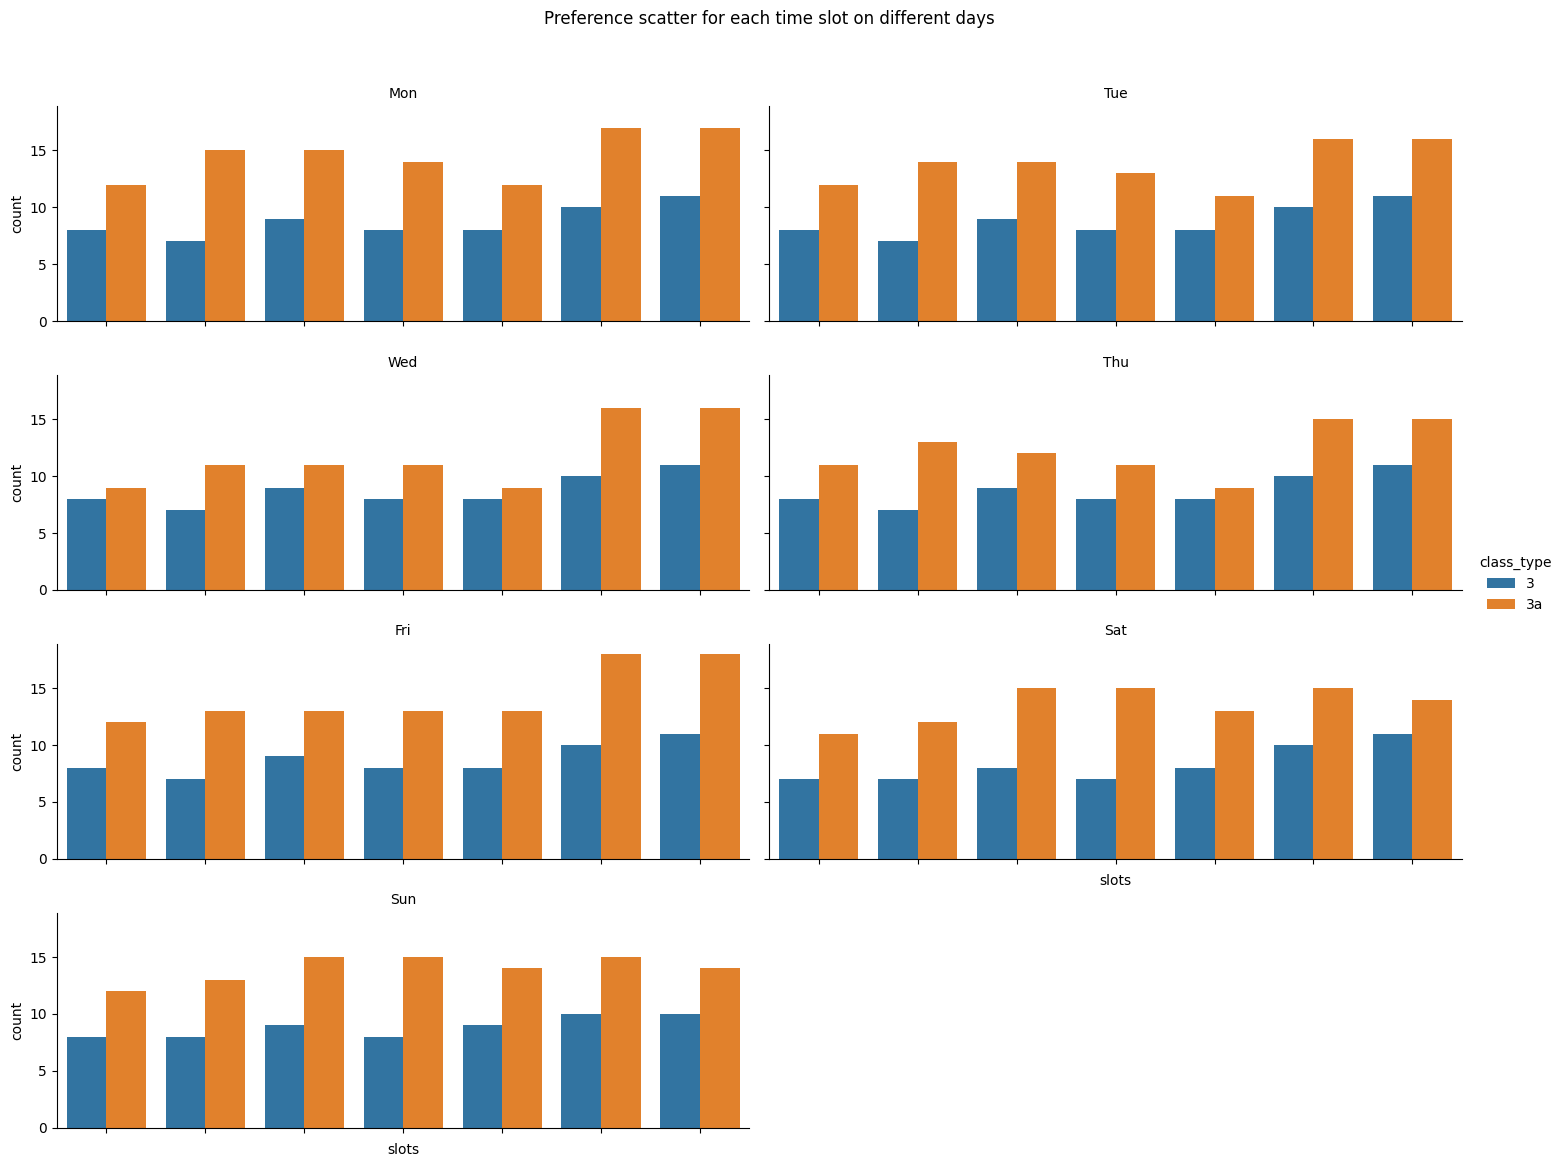

In [19]:
def get_preference_per_day(df: pd.DataFrame):
    count = (
        df.groupby(["day_of_week", "slots", "class_type"])["username"]
          .nunique()
          .reset_index(name="count")
    )
    # Map 0..6 -> Mon..Sun so facet titles are readable
    count["day"] = count["day_of_week"].map(dict(enumerate(week)))

    g = sns.catplot(
        data=count,
        x="slots", y="count", hue="class_type",
        col="day", col_order=week,
        kind="bar",
        col_wrap=2,           # 2 cols x 4 rows; use col_wrap=4 for 4x2, or drop it for one row
        height=3, aspect=2.5,
        sharey=True, sharex=True,
    )
    g.set_titles("{col_name}")
    g.set_xticklabels(rotation=45, ha="right")
    g.figure.suptitle("Preference scatter for each time slot on different days")
    g.figure.subplots_adjust(top=0.9)
    plt.show()

get_preference_per_day(df_melt)

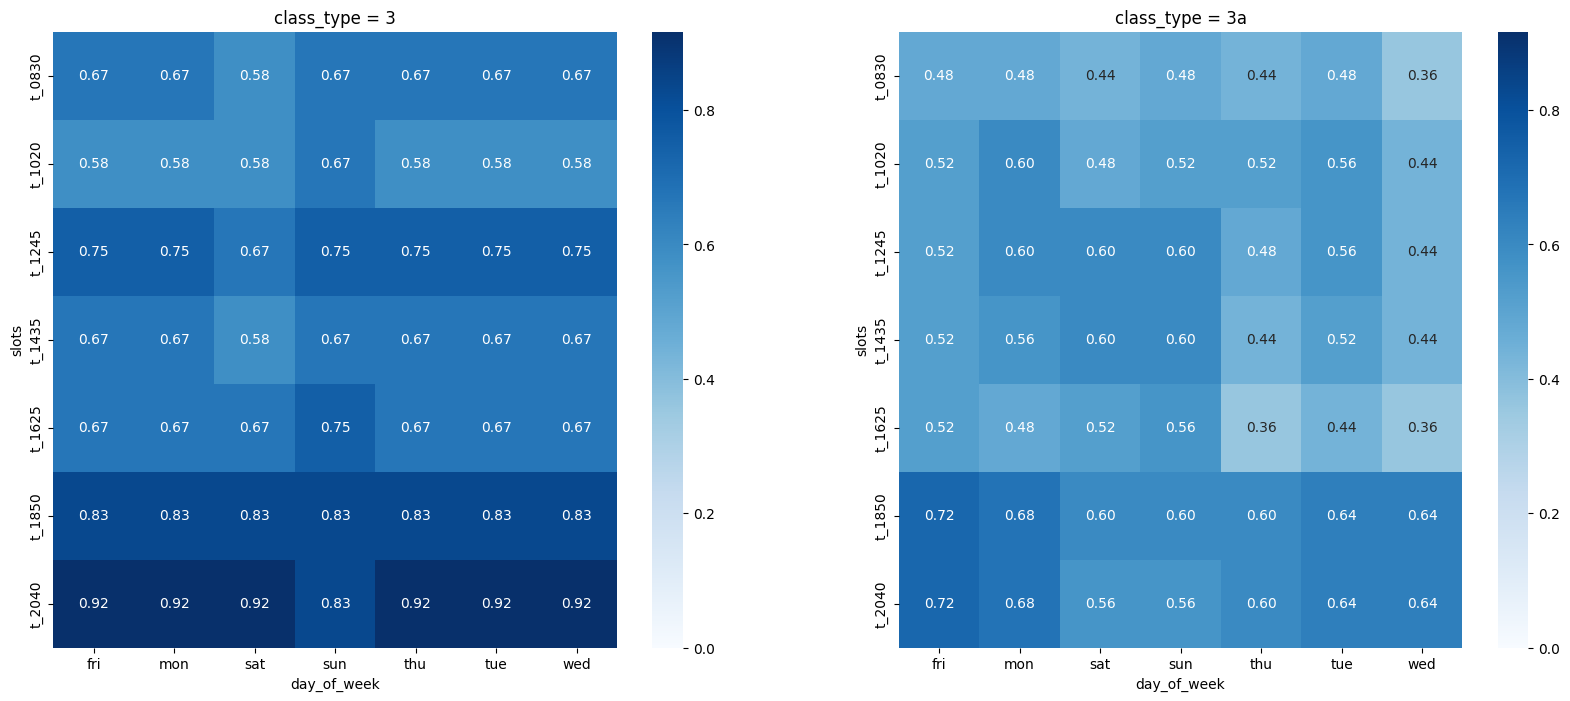

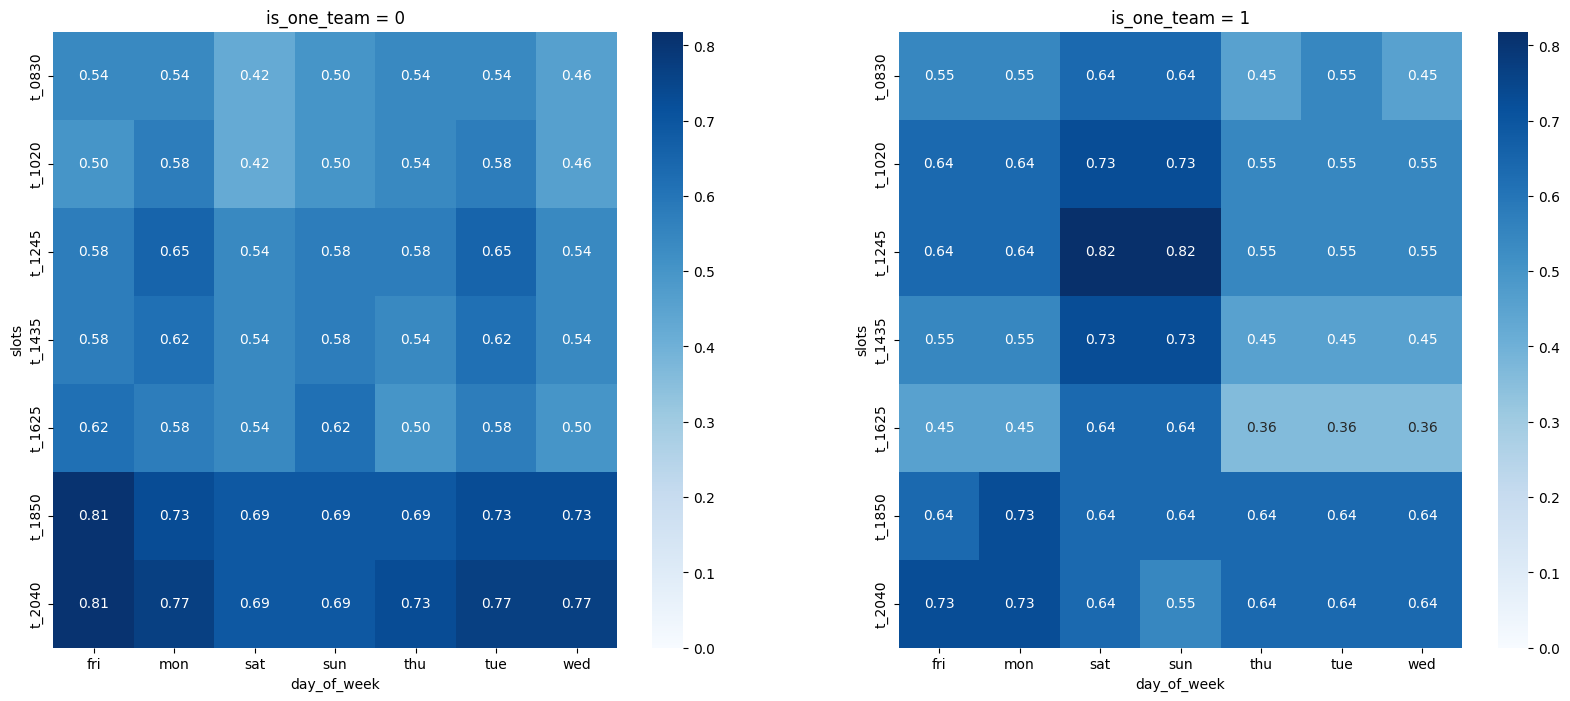

In [20]:
SLOT_ORDER = ["t_0830", "t_1020", "t_1245", "t_1435", "t_1625", "t_1850", "t_2040"]
WEEK_ORDER = ["mon", "tue", "wed", "thu", "fri", "sat", "sun"]

def get_preference_heatmap(df:pd.DataFrame,col:str):
    df = df.copy()
    df["day_of_week"] = df["day_of_week"].map(dict(enumerate(WEEK_ORDER)))
    counts = df.groupby(["day_of_week","slots",col])["username"].nunique().reset_index(name="count")
    total = df.groupby([col])["username"].nunique().reset_index(name="total")
    merged = counts.merge(total,on=[col],how="left")
    merged["share"] = merged["count"] / merged["total"]

    vmax = merged["share"].max()
    groups = df[col].unique()
    fig , axes = plt.subplots(1,len(groups),figsize=(20,8))
    axes = np.atleast_1d(axes)
    for ax,g in zip(axes,groups):
        pv = merged.loc[merged[col]==g].pivot(index="slots",columns="day_of_week",values="share").reindex(index=SLOT_ORDER)
        sns.heatmap(pv,ax=ax,cmap="Blues",vmin=0,vmax=vmax,annot=True,fmt=".2f")
        ax.set_title(f"{col} = {g}")
    

def get_preference_analysis(df:pd.DataFrame):
    get_preference_heatmap(df,"class_type")
    get_preference_heatmap(df,"is_one_team")

    
    

get_preference_analysis(df_melt)

    day_of_week class_type  is_one_team  count
0             0          3            0     20
1             0         3a            0     58
2             0         3a            1      4
3             1          3            0     24
4             1          3            1      5
5             1         3a            0     47
6             1         3a            1      6
7             2          3            0     20
8             2         3a            0     42
9             2         3a            1     12
10            3          3            0     17
11            3          3            1      3
12            3         3a            0     55
13            3         3a            1     42
14            4          3            0     18
15            4          3            1      5
16            4         3a            0     45
17            4         3a            1     24
18            5          3            0     38
19            5         3a            0     14
20           

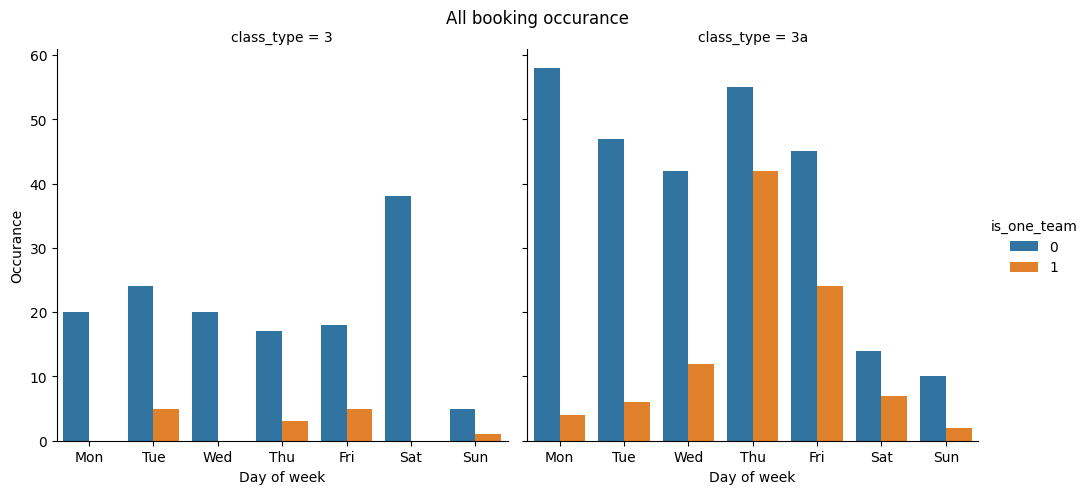

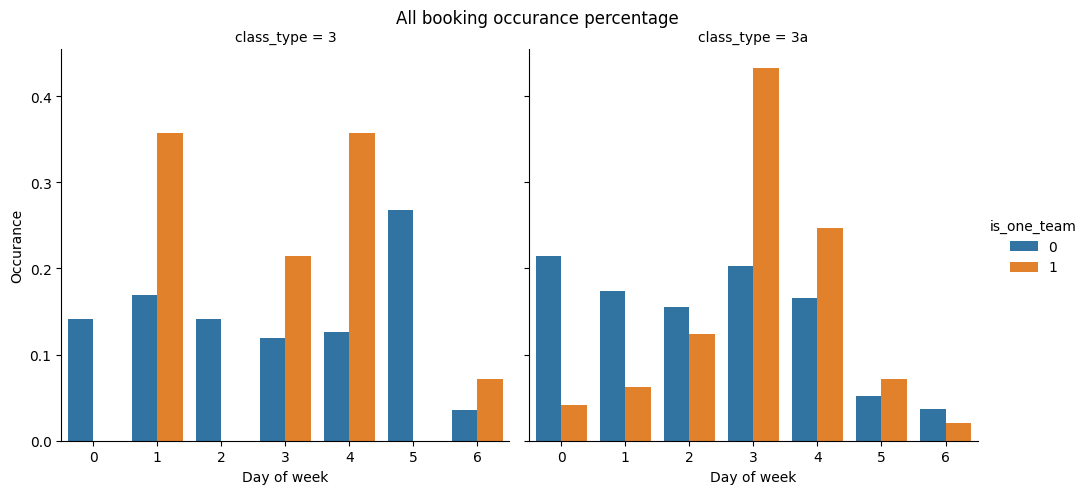

In [21]:
def get_booking_occurance_day(df:pd.DataFrame):
    count = df.groupby(["day_of_week","class_type","is_one_team"])["username"].count().reset_index(name="count")
    print(count)
    g = sns.catplot(data=count,x="day_of_week",y="count",hue="is_one_team",col="class_type",kind="bar",sharex=True,sharey=True)
    g.set_axis_labels("Day of week","Occurance")
    g.figure.suptitle("All booking occurance")
    g.figure.subplots_adjust(top=0.9)
    for ax in g.axes.flat:
        ax.set_xticks(range(len(week)))
        ax.set_xticklabels(week)
        
    
    print(df)
    total = df.groupby(["class_type","is_one_team"])["username"].count().reset_index(name="total")
    print(total)
    merge = count.merge(total,on=["class_type","is_one_team"],how="left")
    merge["share"] = merge["count"]/merge["total"]
    g2=sns.catplot(data=merge,x="day_of_week",y="share",hue="is_one_team",kind="bar",col="class_type")
    g2.set_axis_labels("Day of week","Occurance")
    g2.figure.suptitle("All booking occurance percentage")
    g2.figure.subplots_adjust(top=0.9)
    for ax in g.axes.flat:
        ax.set_xticks(range(len(week)))
        ax.set_xticklabels(week)

    
    

get_booking_occurance_day(df_records)

    day_of_week class_type  is_one_team  count  total
0             0          3            0      6     40
1             0         3a            0     23     89
2             0         3a            1      1     79
3             1          3            0      4     40
4             1          3            1      5     11
5             1         3a            0     10     89
6             1         3a            1      6     79
7             2          3            0     10     40
8             2         3a            0     19     89
9             2         3a            1     11     79
10            3          3            0      8     40
11            3          3            1      1     11
12            3         3a            0     17     89
13            3         3a            1     35     79
14            4          3            0      8     40
15            4          3            1      4     11
16            4         3a            0     16     89
17            4         3a  

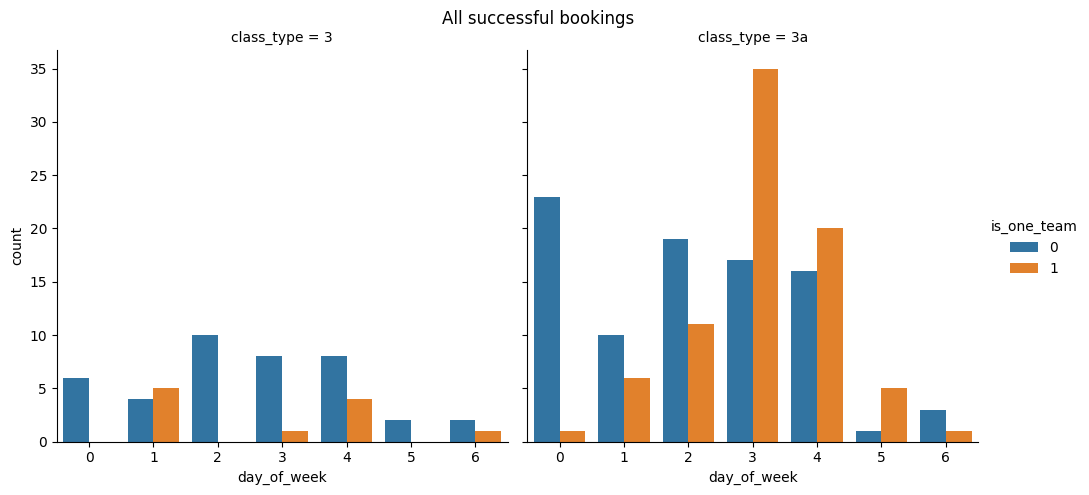

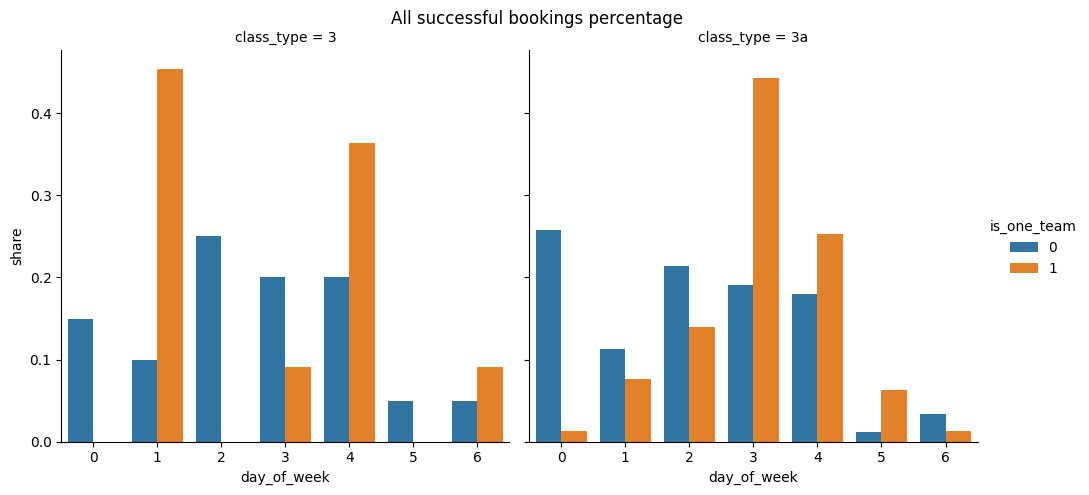

In [22]:
def get_success_booking(df:pd.DataFrame):
    df_success_booking = df.loc[df["booking_type"]==0]

    count = df_success_booking.groupby(["day_of_week","class_type","is_one_team"])["username"].count().reset_index(name="count")
    g = sns.catplot(data=count,x="day_of_week",y="count",hue="is_one_team",col="class_type",kind="bar")
    g.figure.suptitle("All successful bookings")
    g.figure.subplots_adjust(top=0.9)

    total = df_success_booking.groupby(["class_type","is_one_team"])["username"].count().reset_index(name="total")

    merge = count.merge(total,on=["class_type","is_one_team"],how='left')
    print(merge)
    merge["share"] = merge["count"]/merge["total"]
    g2 = sns.catplot(data=merge,x="day_of_week",y="share",hue="is_one_team",col="class_type",kind="bar")
    g2.figure.suptitle("All successful bookings percentage")
    g2.figure.subplots_adjust(top=0.9)


get_success_booking(df_records)

    day_of_week class_type  is_one_team  count  total
0             0          3            0     14    102
1             0         3a            0     35    182
2             0         3a            1      3     18
3             1          3            0     20    102
4             1         3a            0     37    182
5             2          3            0     10    102
6             2         3a            0     23    182
7             2         3a            1      1     18
8             3          3            0      9    102
9             3          3            1      2      3
10            3         3a            0     38    182
11            3         3a            1      7     18
12            4          3            0     10    102
13            4          3            1      1      3
14            4         3a            0     29    182
15            4         3a            1      4     18
16            5          3            0     36    102
17            5         3a  

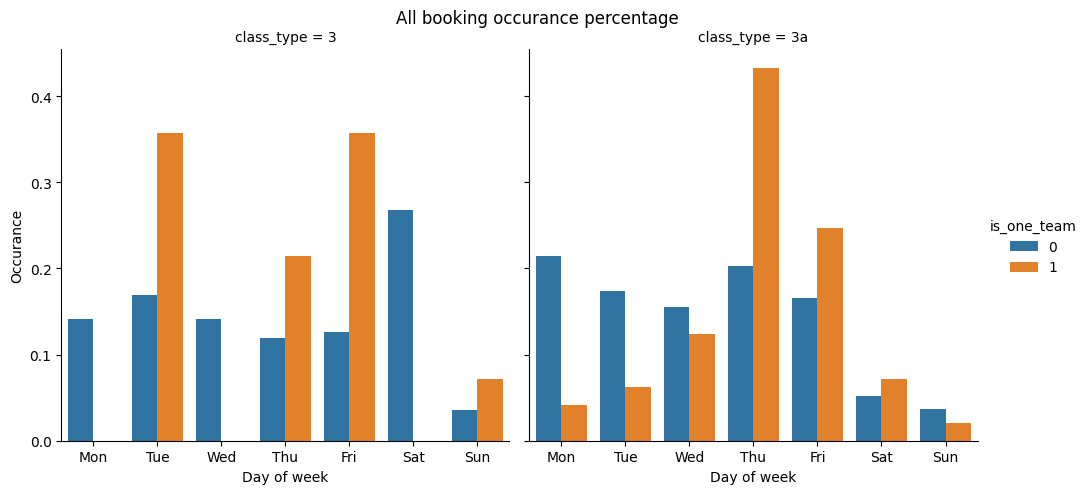

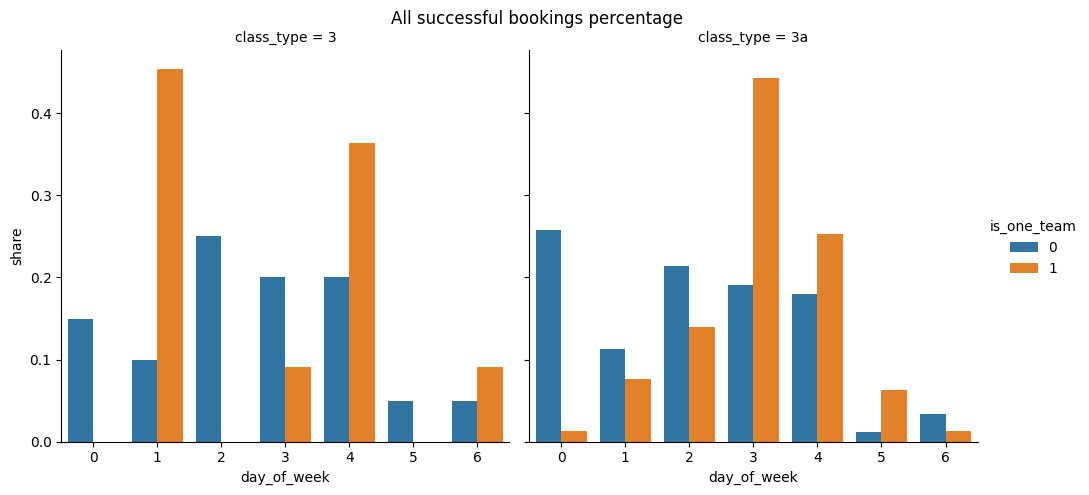

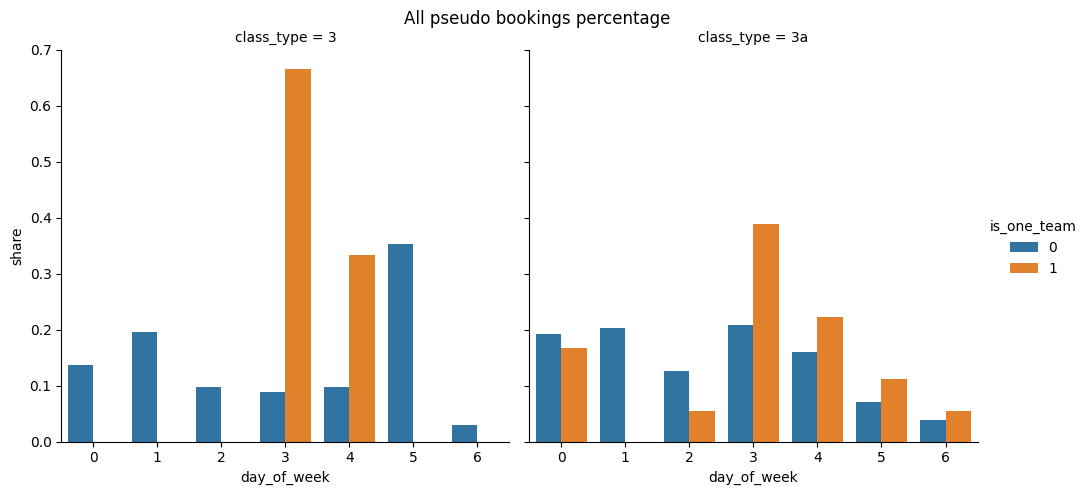

In [23]:
def compare_all_and_success(df):

    count = df.groupby(["day_of_week","class_type","is_one_team"])["username"].count().reset_index(name="count")
    total = df.groupby(["class_type","is_one_team"])["username"].count().reset_index(name="total")
    merge = count.merge(total,on=["class_type","is_one_team"],how="left")
    merge["share"] = merge["count"]/merge["total"]
    g2=sns.catplot(data=merge,x="day_of_week",y="share",hue="is_one_team",kind="bar",col="class_type")
    g2.set_axis_labels("Day of week","Occurance")
    g2.figure.suptitle("All booking occurance percentage")
    g2.figure.subplots_adjust(top=0.9)
    for ax in g2.axes.flat:
        ax.set_xticks(range(len(week)))
        ax.set_xticklabels(week)

    df_success_booking = df.loc[df["booking_type"]==0]
    count = df_success_booking.groupby(["day_of_week","class_type","is_one_team"])["username"].count().reset_index(name="count")
    total = df_success_booking.groupby(["class_type","is_one_team"])["username"].count().reset_index(name="total")
    merge = count.merge(total,on=["class_type","is_one_team"],how='left')
    merge["share"] = merge["count"]/merge["total"]
    g2 = sns.catplot(data=merge,x="day_of_week",y="share",hue="is_one_team",col="class_type",kind="bar")
    g2.figure.suptitle("All successful bookings percentage")
    g2.figure.subplots_adjust(top=0.9)

    df_pseudo_booking = df.loc[~(df["booking_type"]==0)]
    count = df_pseudo_booking.groupby(["day_of_week","class_type","is_one_team"])["username"].count().reset_index(name="count")
    total = df_pseudo_booking.groupby(["class_type","is_one_team"])["username"].count().reset_index(name="total")
    merge = count.merge(total,on=["class_type","is_one_team"],how='left')
    print(merge)
    merge["share"] = merge["count"]/merge["total"]
    g3 = sns.catplot(data=merge,x="day_of_week",y="share",hue="is_one_team",col="class_type",kind="bar")
    g3.figure.suptitle("All pseudo bookings percentage")
    g3.figure.subplots_adjust(top=0.9)
compare_all_and_success(df_records)

    hour class_type  is_one_team  count
0      0         3a            0      2
1      0         3a            1     18
2      1          3            1      1
3      1         3a            0      3
4      2         3a            0      1
..   ...        ...          ...    ...
64    22          3            0      2
65    22         3a            0      2
66    22         3a            1      3
67    23         3a            0      4
68    23         3a            1      1

[69 rows x 4 columns]


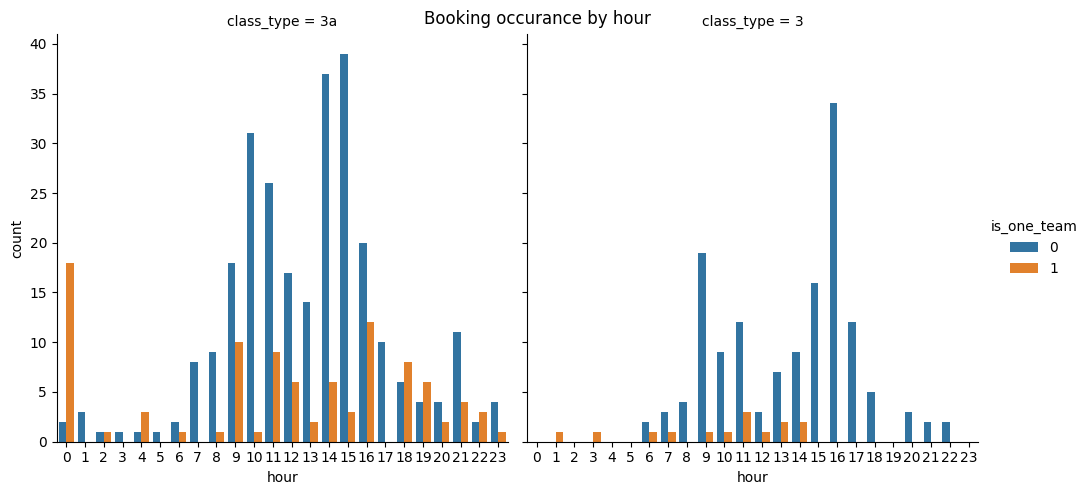

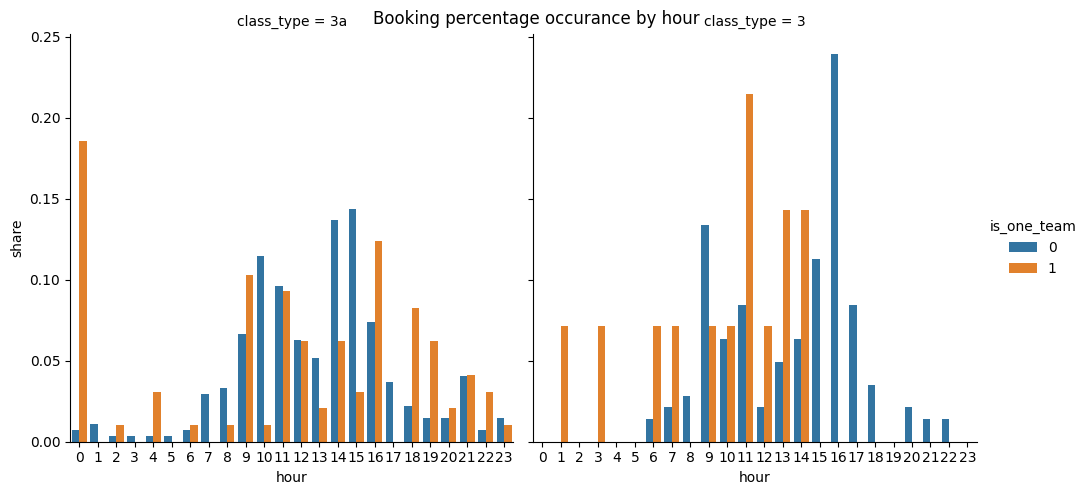

In [24]:
def get_booking_timing(df:pd.DataFrame):
    df = df.assign(hour=df["booking_at"].dt.hour)
    count = df.groupby(["hour","class_type","is_one_team"])["username"].count().reset_index(name="count")
    print(count)
    g = sns.catplot(data=count,x="hour",y="count",hue="is_one_team",col="class_type",kind="bar")
    g.figure.suptitle("Booking occurance by hour")

    total = df.groupby(["class_type","is_one_team"])["username"].count().reset_index(name="total")
    merge= count.merge(total,on=["class_type","is_one_team"],how="left")
    merge["share"] = merge["count"]/merge["total"]

    g2 = sns.catplot(data=merge,x="hour",y="share",hue="is_one_team",col="class_type",kind="bar")
    g2.figure.suptitle("Booking percentage occurance by hour")


get_booking_timing(df_records)

    hour class_type  is_one_team  count
0      0         3a            0      1
1      0         3a            1     16
2      1          3            1      1
3      1         3a            0      3
4      2         3a            0      1
..   ...        ...          ...    ...
59    21         3a            0      4
60    21         3a            1      2
61    22          3            0      1
62    22         3a            1      3
63    23         3a            1      1

[64 rows x 4 columns]


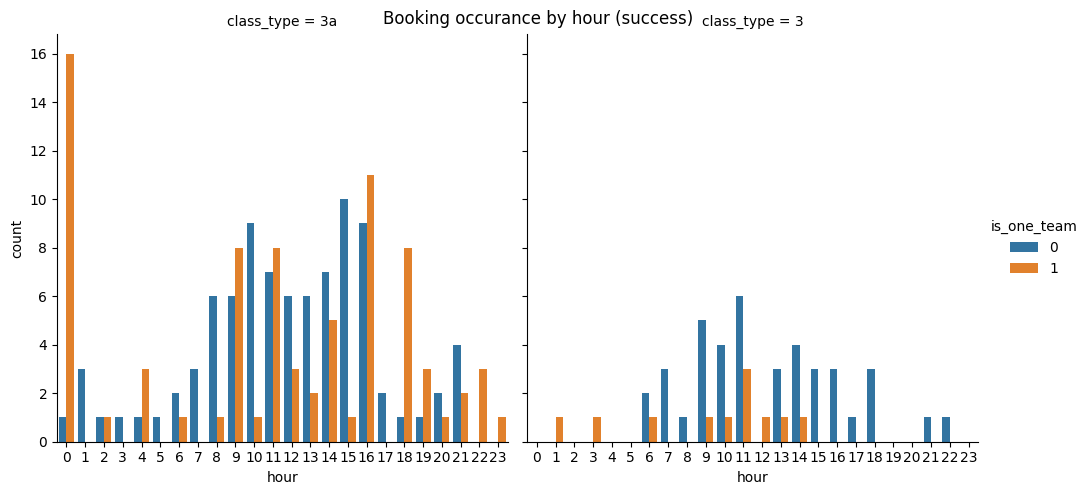

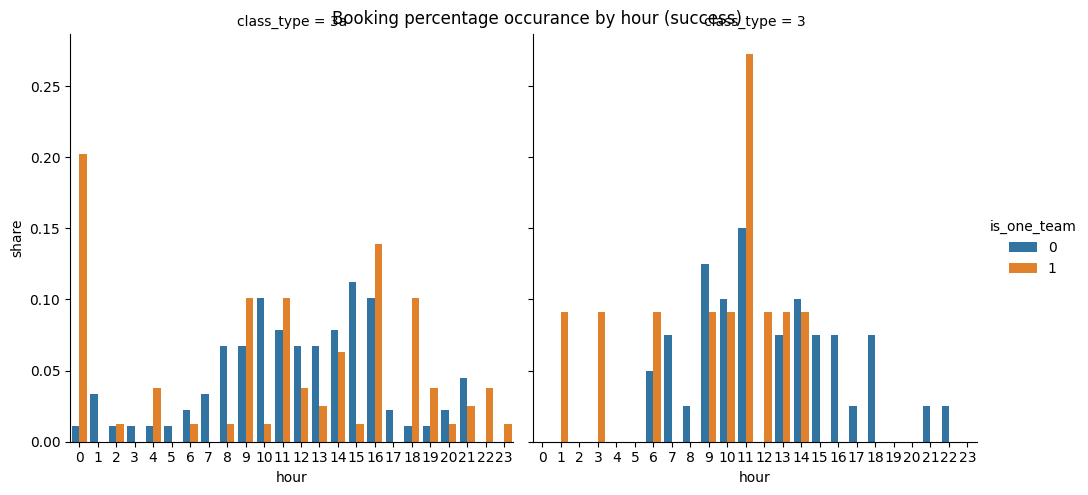

In [25]:

def get_success_booking_timing(df:pd.DataFrame):
    df = df.assign(hour=df["booking_at"].dt.hour).loc[df["booking_type"]==0]
    count = df.groupby(["hour","class_type","is_one_team"])["username"].count().reset_index(name="count")
    print(count)
    g = sns.catplot(data=count,x="hour",y="count",hue="is_one_team",col="class_type",kind="bar")
    g.figure.suptitle("Booking occurance by hour (success)")

    total = df.groupby(["class_type","is_one_team"])["username"].count().reset_index(name="total")
    merge= count.merge(total,on=["class_type","is_one_team"],how="left")
    merge["share"] = merge["count"]/merge["total"]

    g2 = sns.catplot(data=merge,x="hour",y="share",hue="is_one_team",col="class_type",kind="bar")
    g2.figure.suptitle("Booking percentage occurance by hour (success)")


get_success_booking_timing(df_records)

    hour class_type  is_one_team  count
0      0         3a            0      1
1      0         3a            1      2
2      7          3            1      1
3      7         3a            0      5
4      8          3            0      3
5      8         3a            0      3
6      9          3            0     14
7      9         3a            0     12
8      9         3a            1      2
9     10          3            0      5
10    10         3a            0     22
11    11          3            0      6
12    11         3a            0     19
13    11         3a            1      1
14    12          3            0      3
15    12         3a            0     11
16    12         3a            1      3
17    13          3            0      4
18    13          3            1      1
19    13         3a            0      8
20    14          3            0      5
21    14          3            1      1
22    14         3a            0     30
23    14         3a            1      1


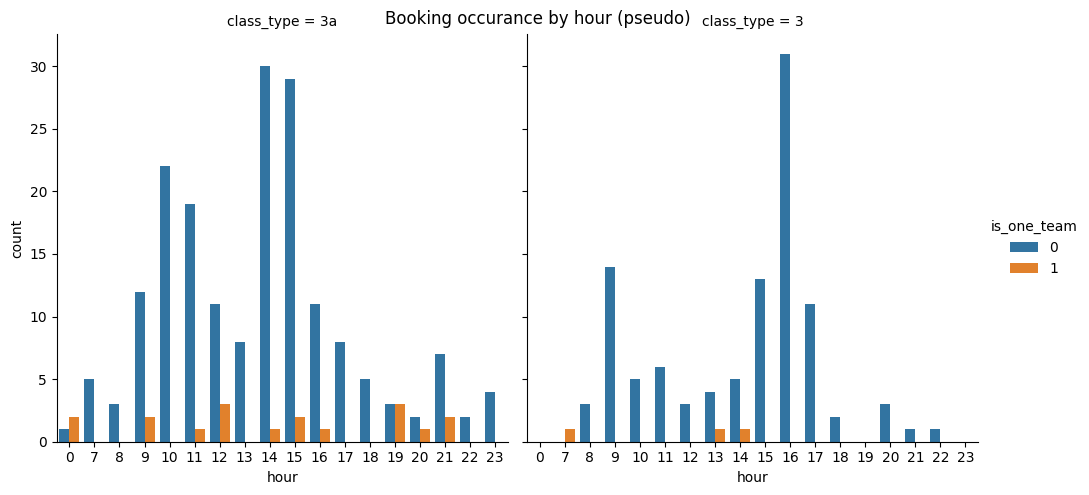

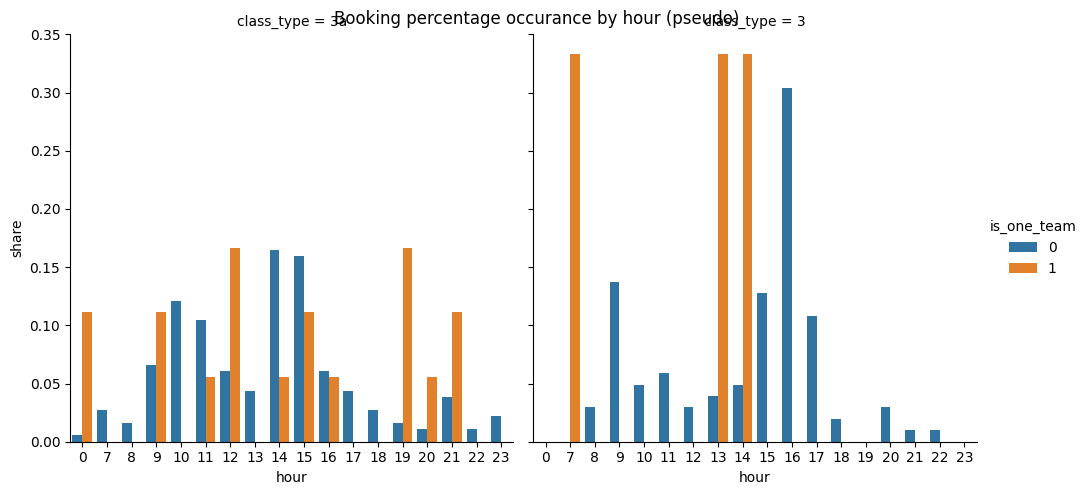

In [26]:

def get_pseudo_booking_timing(df:pd.DataFrame):
    df = df.assign(hour=df["booking_at"].dt.hour).loc[df["booking_type"]!=0]
    count = df.groupby(["hour","class_type","is_one_team"])["username"].count().reset_index(name="count")
    print(count)
    g = sns.catplot(data=count,x="hour",y="count",hue="is_one_team",col="class_type",kind="bar")
    g.figure.suptitle("Booking occurance by hour (pseudo)")

    total = df.groupby(["class_type","is_one_team"])["username"].count().reset_index(name="total")
    merge= count.merge(total,on=["class_type","is_one_team"],how="left")
    merge["share"] = merge["count"]/merge["total"]

    g2 = sns.catplot(data=merge,x="hour",y="share",hue="is_one_team",col="class_type",kind="bar")
    g2.figure.suptitle("Booking percentage occurance by hour (pseudo)")


get_pseudo_booking_timing(df_records)

In [27]:
oneteam_success = len(df_records.loc[(df_records["is_one_team"]==1) &  (df_records["booking_type"]==0)])
oneteam_overall = len(df_records.loc[(df_records["is_one_team"]==1) ])
print(oneteam_success/oneteam_overall)


none_oneteam_success = len(df_records.loc[(df_records["is_one_team"]==0) &  (df_records["booking_type"]==0)])
none_oneteam_overall = len(df_records.loc[(df_records["is_one_team"]==0) ])
print(none_oneteam_success/none_oneteam_overall)

class_3_0_success = len(df_records.loc[(df_records["class_type"]=="3") & (df_records["is_one_team"]==0) &  (df_records["booking_type"]==0)])
class_3_0_overall = len(df_records.loc[(df_records["class_type"]=="3") & df_records["is_one_team"]==0 ])
print(class_3_0_success/ class_3_0_overall)

class_3_1_success = len(df_records.loc[(df_records["class_type"]=="3") &(df_records["is_one_team"]==1)&  (df_records["booking_type"]==0)])
class_3_1_overall = len(df_records.loc[(df_records["class_type"]=="3") & (df_records["is_one_team"]) ==1])
print(class_3_1_success/ class_3_1_overall)

class_3a_0_success = len(df_records.loc[(df_records["class_type"]=="3a") &  (df_records["is_one_team"]==0) & (df_records["booking_type"]==0)])
class_3a_0_overall = len(df_records.loc[(df_records["class_type"]=="3a") & (df_records["is_one_team"]==0)])
print(class_3a_0_success/ class_3a_0_overall)

class_3a_1_success = len(df_records.loc[(df_records["class_type"]=="3a") &(df_records["is_one_team"]==1)&  (df_records["booking_type"]==0)])
class_3a_1_overall = len(df_records.loc[(df_records["class_type"]=="3a") & (df_records["is_one_team"]) ==1])
print(class_3a_1_success/ class_3a_1_overall)

0.8108108108108109
0.31234866828087166
0.0784313725490196
0.7857142857142857
0.3284132841328413
0.8144329896907216


In [45]:
test = df_records.assign(hour=df_records["booking_at"].dt.hour)
total_between_1_7 = test.loc[ test["hour"].between(1,6) ]
success_between_1_7 = test.loc[ test["hour"].between(1,6) & (test["booking_type"]==0)]

print(len(total_between_1_7))

print(len(success_between_1_7)/len(total_between_1_7))


19
1.0


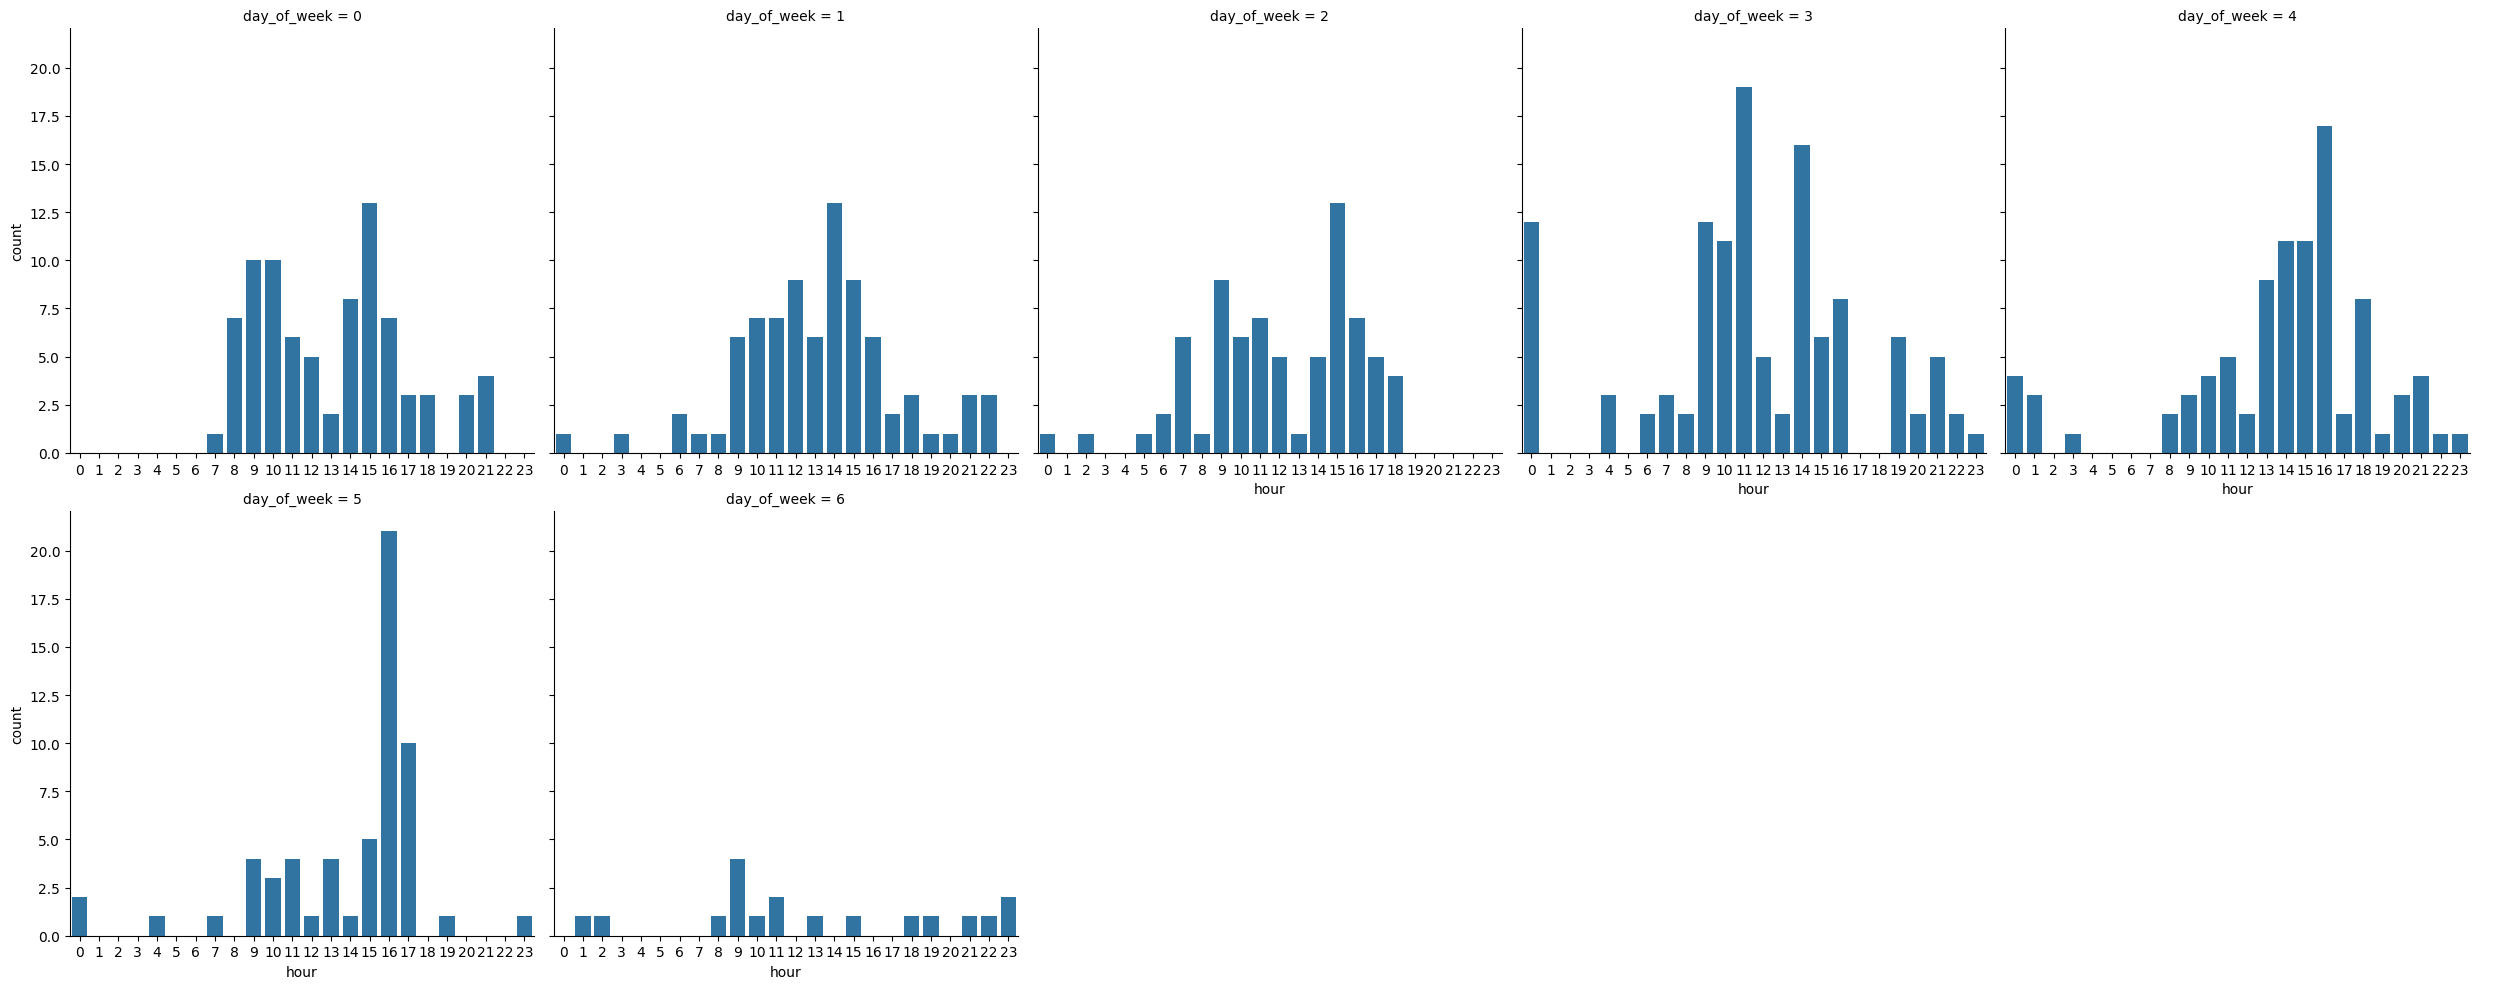

In [57]:
def get_booking_per_day_timeslots(df:pd.DataFrame):
    df = df.assign(hour=df["booking_at"].dt.hour)
    count= df.groupby(["day_of_week","hour"])["username"].count().reset_index(name="count")
    week = range(7)
    hours = range(24)
    idx = pd.MultiIndex.from_product([week, hours], names=["day_of_week", "hour"])
    count = (count.set_index(["day_of_week", "hour"])
                  .reindex(idx, fill_value=0)
                  .reset_index())
    
    sns.catplot(data=count,x="hour",y="count",kind="bar",col="day_of_week",col_wrap=5,sharex=False)

get_booking_per_day_timeslots(df_records)